In [2]:
import torch
import sys
import os

### Test an Image

In [20]:
import numpy as np
import pandas as pd
import cv2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURE_MODEL = 'NetVlad'
groundtruth_df = pd.read_csv(f"/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/Mahidol_University/ICT/1.1_{FEATURE_MODEL}/groundtruth_img_dataset_ICT_1.1_{FEATURE_MODEL}_10P.csv")
image_filepaths = groundtruth_df["image_name"].apply(lambda x : f"/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/Mahidol_University/ICT/1.1_NetVlad/perspectives/{x}.png").tolist()
test_image_path = image_filepaths[0]

def get_image_tensor( test_image_path ):
    img = cv2.imread(test_image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot load test image: {test_image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0

# images = img
# new_side_len = min(images.shape[-1], images.shape[-2]) // 14 * 14    # dimensions must be divisible by 14
# resized_imgs = transforms.CenterCrop((new_side_len, new_side_len))(images)
# encodings, descriptors = self.model(resized_imgs)



## Model PT Weights

In [21]:
netvlad_pth = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/parameters/netvlad/paper/checkpoints/checkpoint.pth.tar"
crica_pth = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/parameters/CricaVPR/ckpts/CricaVPR.pth"
mixvpr_pth = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/parameters/MixVPR/ckpts/resnet50_MixVPR_4096_channels(1024)_rows(4).ckpt"
dinov2salad_pth = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/parameters/DinoV2Salad/ckpts/dino_salad.ckpt"

In [22]:
netvlad_state_dict = torch.load(netvlad_pth)
crica_state_dict = torch.load(crica_pth)
mixvpr_state_dict = torch.load(mixvpr_pth)
dinov2salad_state_dict = torch.load(dinov2salad_pth)

/tmp/ipykernel_2804025/2739233192.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netvlad_state_dict = torch.load(netvlad_pth)
/tmp/ipykernel_2804025/2739233192.py:2: Fu

In [32]:
# netvlad_state_dict
# crica_state_dict["model_state_dict"]
# crica_state_dict["epoch_num"]
# mixvpr_state_dict
# dinov2salad_state_dict

### CricaVPR

In [39]:
from torchvision import transforms

def preprocess_crica(images):
    new_side_len = min(images.shape[-1], images.shape[-2]) // 14 * 14    # dimensions must be divisible by 14
    return transforms.CenterCrop((new_side_len, new_side_len))(images)

In [24]:
module_dir = os.path.abspath('/home/nattachart.tak/PhD/Trial_New_UNav/UNav/unav/core/third_party')
sys.path.append(module_dir)
from CricaVPR.util import resume_model
from CricaVPR.network import CricaVPRNet
from CricaVPR.feature_extract import CricaVPRFeatureExtractor
root = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/"
content = {
            "ckpt_path": 'parameters/CricaVPR/ckpts/CricaVPR.pth',
            "cuda": True,
            "model_resize": [320, 320]
        }
m = CricaVPRFeatureExtractor(root, content)

tensor_img = get_image_tensor( test_image_path )
tensor_img.shape
m(tensor_img)

CricaVPR loaded from /home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/parameters/CricaVPR/ckpts/CricaVPR.pth successfully!


(tensor([[[[-7.1782e-01, -7.6860e-01, -3.1445e-01,  ...,  6.1883e-01,
             1.2203e+00,  6.9190e-01],
           [-8.2620e-01, -1.0918e+00, -2.9257e+00,  ...,  6.3905e-01,
             6.8932e-01,  4.4823e-01],
           [-3.5434e+00, -4.0798e+00, -3.5969e+00,  ...,  8.7550e-01,
             3.4304e-01, -6.8541e-01],
           ...,
           [-4.3926e+00, -2.8674e-01, -4.3143e-01,  ...,  2.2848e+00,
             1.6564e+00,  2.2822e+00],
           [-4.7323e+00, -4.8379e+00, -2.8798e-01,  ...,  2.9333e+00,
             2.5189e+00,  3.2476e+00],
           [-3.8237e+00, -2.7546e+00, -2.7728e+00,  ...,  2.1742e+00,
             2.7873e+00,  2.3328e+00]],
 
          [[ 9.8416e-02, -5.1022e-02,  1.6640e+00,  ...,  1.3244e+00,
             1.4178e+00,  5.8739e-01],
           [-1.5854e-01, -6.3644e-01,  9.7937e-01,  ...,  3.2584e+00,
             1.8778e+00,  4.1362e-01],
           [ 2.8859e-01, -1.3410e+00,  5.7465e-01,  ...,  3.3674e+00,
             2.0692e+00,  5.9511e-01],


### NetVLAD

In [10]:
module_dir = os.path.abspath('/home/nattachart.tak/PhD/Trial_New_UNav/UNav/unav/core/third_party')
sys.path.append(module_dir)
from pytorch_NetVlad.Feature_Extractor import NetVladFeatureExtractor
root = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/"
content = {
            "ckpt_path": 'parameters/netvlad/paper/checkpoints',
            "arch": 'vgg16',
            "num_clusters": 64,
            "pooling": 'netvlad',
            "vladv2": False,
            "nocuda": False,
            "model_resize": [480, 640]
        }

model_conf = content
m = NetVladFeatureExtractor(
    os.path.join(root, model_conf["ckpt_path"]),
    type="pipeline" if pipeline else None,
    arch=model_conf['arch'],
    num_clusters=model_conf['num_clusters'],
    pooling=model_conf['pooling'],
    vladv2=model_conf['vladv2'],
    nocuda=model_conf['nocuda']
)

tensor_img = get_image_tensor( test_image_path )
tensor_img.shape
m(tensor_img)

NameError: name 'pipeline' is not defined

### AnyLOC

In [12]:
module_dir = os.path.abspath('/home/nattachart.tak/PhD/Trial_New_UNav/UNav/unav/core/third_party')
sys.path.append(module_dir)
from AnyLoc.feature_extract import VLADDinoV2FeatureExtractor

root = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/"
content = {
            "model_type": 'dinov2_vitg14',
            "ckpt_path": 'None',
            "max_image_size": 1024,
            "desc_layer": 31,
            "desc_facet": 'value',
            "num_clusters": 32,
            "domain": 'indoor',
            "cache_dir": 'parameters/AnyLoc/demo/cache',
            "cuda": True,
            "model_resize": [224, 224]
        }
img_model = VLADDinoV2FeatureExtractor(root, content)


/unav/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'fast_pytorch_kmeans'

# Magnetometer

In [ ]:
# def get_data()->pd.DataFrame: pass

In [48]:
import sys, os
import numpy as np
import torch
module_dir = os.path.abspath('/home/nattachart.tak/PhD/Trial_New_UNav/UNav/unav/core/third_party')
sys.path.append(module_dir)
# print(np.array([f for f in sorted(list(sys.modules.keys())) if 'Magnet' in f]))
import importlib
import Magnetometer.feature_extract 
importlib.reload(Magnetometer.feature_extract)
import Magnetometer.feature_extract 

root = "/home/nattachart.tak/Data/experiments/Mapping/data/unav2-data/"
content = {
            "model_path": '/home/nattachart.tak/PhD/Trial_New_UNav/UNav/unav/core/third_party/Magnetometer/unfitted_pytorch.pth',
            'n_outputs':2,
            'n_inputs':39,
            'preprocess': 'SpectralV5',
            'cuda': True
        }

mag_model = Magnetometer.feature_extract.MagFeatureExtractor(root, content)
batch_sample = np.random.sample(150).reshape(50,3)

pred = mag_model(batch_sample)
pred

././././././././


(tensor([-0.1497,  0.6023], device='cuda:0', grad_fn=<ViewBackward0>), None)

In [8]:
mag_features = features[0].detach().numpy()

array([-0.23931363,  0.59609383], dtype=float32)

## Visualize

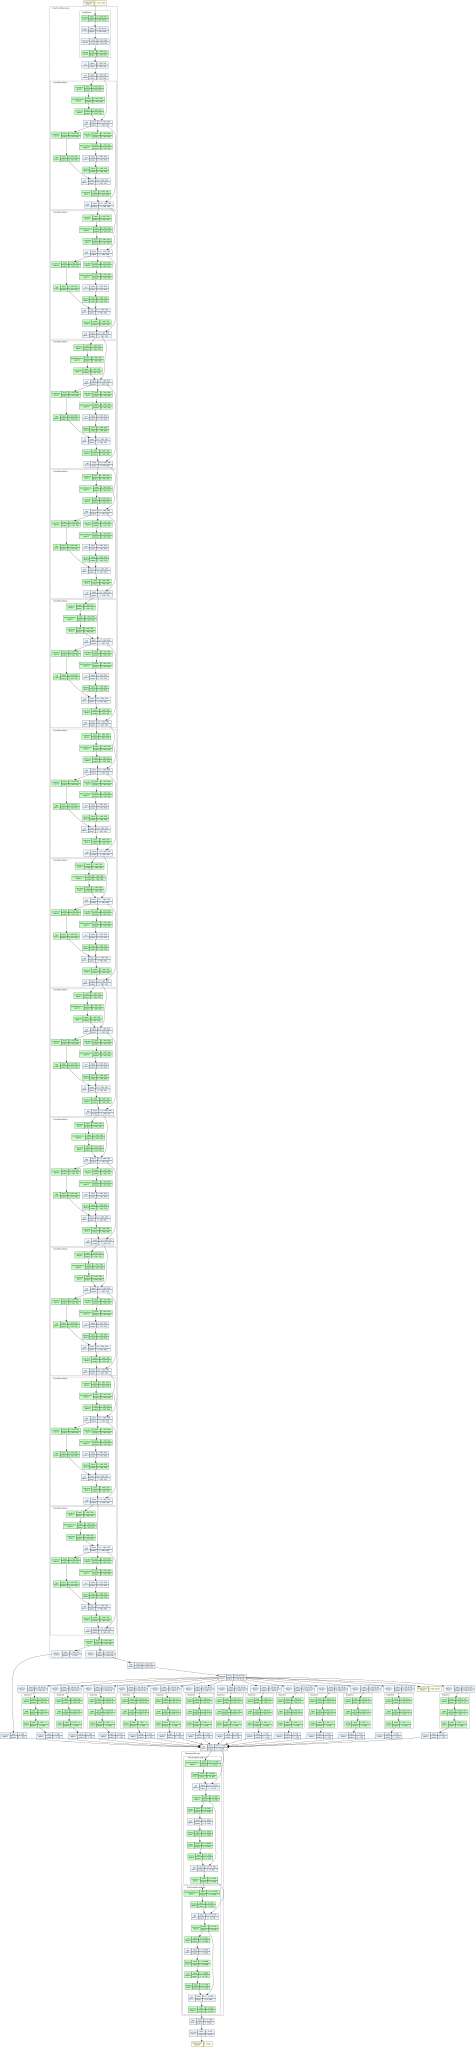

In [36]:
from torchview import draw_graph

    

model_graph = draw_graph(m.model, input_size=preprocess_crica(tensor_img).shape, expand_nested=True)
model_graph.visual_graph

# DMFM
- 

In [96]:
import torch.nn as nn

#img_features, mag_features
class FusedModule(nn.Module):
    def __init__(self, in_channels, compress_ratio):
        super(FusedModule, self).__init__()

        channels = int(in_channels/compress_ratio)
        out_channels = in_channels
        
        self.lin1 = nn.Linear(in_channels, channels)
        self.lin2 = nn.Linear(channels, 3*in_channels)

        # self.lin3 = nn.Linear(4*in_channels, out_channels)
        self.relu = nn.ReLU()
        # self.bn = nn.BatchNorm1d(in_channels)
        self.drop = nn.Dropout1d(p=0.4)   
        
    def forward(self, x,y):
        z = torch.cat((x, y), dim=1)
        identity = z

        z1 = self.lin1(z)
        z1 = self.relu(z1)
        z1 = self.drop(z1)
        z1 = self.lin2(z1)
        z1 = self.relu(z1)
        z1 = self.drop(z1)

        out = torch.cat((z1, identity), dim=1)
        
        return out

class ImgMagModel(nn.Module):
    def __init__(self, in_channels, compress_ratio, img_model, mag_model, out_class):
#     def __init__(self, img_model, out_class):

        super().__init__()
        self.img_model = img_model
        self.mag_model = mag_model
        self.fused = FusedModule(in_channels, compress_ratio)
    
        # self.relu = nn.ReLU()
        # self.drop = nn.Dropout1d(p=0.4)    
        # self.fc = nn.Linear(1024*4, out_class) #1024,2048
        # self.norm = nn.BatchNorm1d(out_class)


    def forward(self, x, y):
        # image
        x = self.img_model(x)[1]
              
        # mag
        y = self.mag_model(y).reshape(1,2)
        
        # fusion the outputs
        z = self.fused(x,y)

        # pass through fully connected layers
        # z = self.fc(z)
        # z = self.norm(z)
        # z = self.relu(z)
        return z

In [97]:
img_model = m
model = ImgMagModel(10754, 32, img_model.model, mag_model.model, 2)
model = model.to(device)

model(
preprocess_crica(img), torch.tensor( mag_model.preprocess(batch_sample), dtype=torch.float32 ).to(device)
     ).shape

torch.Size([1, 43016])

In [100]:
43016/10754

4.0

In [71]:
x = mag_model.model(torch.tensor( mag_model.preprocess(batch_sample), dtype=torch.float32 ).to(device)).reshape(1,2)

In [72]:
y = img_model.model(preprocess_crica(img))[1]

In [73]:
z = torch.cat((x, y), dim=1)

In [82]:
z = z.to('cpu')

In [92]:
z.shape

torch.Size([1, 10754])

In [87]:
def f(z):
    in_channels = 10754
    compress_ratio = 32
    
    channels = int(in_channels/compress_ratio)
    out_channels = in_channels
    
    lin1 = nn.Linear(in_channels, channels)
    lin2 = nn.Linear(channels, 2*in_channels)
    
    # self.lin3 = nn.Linear(4*in_channels, out_channels)
    relu = nn.ReLU()
    # self.bn = nn.BatchNorm1d(in_channels)
    drop = nn.Dropout1d(p=0.4)  
    
    identity = z
    
    z1 = lin1(z)
    z1 = relu(z1)
    z1 = drop(z1)
    
    z1 = lin2(z1)
    z1 = relu(z1)
    z1 = drop(z1)

    out = torch.cat((z1, identity), dim=1)

    return z1


In [88]:
f(z).shape

torch.Size([1, 21508])